<center>

# Analytical creation of Na2Ca3Al2F14 sample

</center>

#### Author: Daniel Lomholt Christensen

In [1]:
# Brug uden absorption i powdern

# Test absorption in Union

# Evt. samme test som incoherent.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mcstasscript as ms

In [63]:
# Try to read in reflections from Ncrystal
form_ncrystal = pd.read_table('NaCaAlf.laz', sep=r'\s+', header=None, comment='#')
form_ncrystal = np.array([form_ncrystal[3],form_ncrystal[4],form_ncrystal[5]])
form_fullprof = np.loadtxt('Full_test.hkl', skiprows=3)
form_fullprof = form_fullprof[:,3:]
full_q_list = {}
for refl in range(len(form_fullprof[:,0])):
    if (form_fullprof[refl,3])>7.5:
        continue
    if (form_fullprof[refl,3])<1.7:
        break
    form_factor = form_fullprof[refl,5]
    # print(f"|F|={form_factor/100:.3f}\tmult={form_ncrystal[2,i]}\tQ = {2*np.pi/form_ncrystal[3,i]:.6f}\tTheta={form_ncrystal[0,i]:.4g}")
    if round(form_fullprof[refl,4],4) not in full_q_list.keys():
        full_q_list[round(form_fullprof[refl,4],4)] = form_factor*form_fullprof[refl,0]
        # print('Adding')
    else:
        # print(i)
        full_q_list[round(form_fullprof[refl,4],4)] += form_factor*form_fullprof[refl,0]
full_q_list = np.array(sorted(full_q_list.items()))
print(full_q_list)

[[8.66300000e-01 1.10770800e+01]
 [1.22520000e+00 9.96619800e+01]
 [1.50050000e+00 2.10187920e+02]
 [1.73260000e+00 4.85246160e+02]
 [1.93710000e+00 1.01418600e+02]
 [2.12200000e+00 1.98910960e+02]
 [2.29200000e+00 3.47982480e+02]
 [2.45030000e+00 3.31516980e+02]
 [2.59890000e+00 8.35853520e+02]
 [2.73950000e+00 1.27966620e+03]
 [2.87320000e+00 3.53154240e+03]
 [3.00100000e+00 7.74780000e+01]
 [3.12350000e+00 3.50199336e+03]
 [3.35520000e+00 3.44875440e+03]
 [3.46520000e+00 2.82446004e+03]
 [3.57190000e+00 4.15609560e+02]
 [3.67550000e+00 8.89944420e+02]]


In [74]:
# Loop over D spacings
q_list = {}
for i in range(len(form_ncrystal[0])):
    if form_ncrystal[1,i]>7.5:
        continue
    if form_ncrystal[1,i]<1.7:
        break
    
    form_factor = form_ncrystal[2,i]
    # print(f"|F|={form_factor/100:.3f}\tmult={form_ncrystal[2,i]}\tQ = {2*np.pi/form_ncrystal[3,i]:.6f}\tTheta={form_ncrystal[0,i]:.4g}")
    if 2*np.pi/form_ncrystal[1,i] not in q_list.keys():
        q_list[2*np.pi/form_ncrystal[1,i]] = form_factor*form_ncrystal[0,i]
        # print('Adding')
    else:
        # print(i)
        q_list[2*np.pi/form_ncrystal[1,i]] += form_factor*form_ncrystal[0,i]
q_list = np.array(sorted(q_list.items()))
print(q_list)

[[8.66312360e-01 1.99547152e+01]
 [1.22515069e+00 7.88694189e+01]
 [1.50049702e+00 2.74590615e+02]
 [1.73262472e+00 4.04624265e+02]
 [1.93713333e+00 1.64099319e+02]
 [2.12202324e+00 2.92242809e+02]
 [2.29204706e+00 3.11004989e+02]
 [2.45030138e+00 2.14653111e+02]
 [2.59893708e+00 7.51199009e+02]
 [2.73952022e+00 1.31359812e+03]
 [2.87323305e+00 3.24734841e+03]
 [3.00099405e+00 4.45554781e+01]
 [3.12353363e+00 3.52168887e+03]
 [3.35521334e+00 3.41451063e+03]
 [3.46524944e+00 2.88347685e+03]
 [3.57189736e+00 3.43821263e+02]
 [3.67545207e+00 6.83878555e+02]]


In [69]:
# # Load the powder structure and generate the theoretical diffractogram
# Load in Structure factor from Vesta

def get_formfact(file):
    data_from_cif = pd.read_table(file, sep=r'\s+', header=0)
    # data_from_cif = pd.read_table("Copper.txt", sep=r'\s+', header=0)

    cif = np.array([data_from_cif['2θ'],data_from_cif['|F|'],data_from_cif['M'], data_from_cif['d(Å)']] )

    theta_list = {}
    for i in range(len(cif[0])):
        if cif[0,i]>100 or np.isnan(cif[0,i]):
            continue
        print(cif[3,i])
        
        form_factor = cif[1,i]**2
        # print(f"|F|={form_factor/100:.3f}\tmult={cif[2,i]}\tQ = {2*np.pi/cif[3,i]:.6f}\tTheta={cif[0,i]:.4g}")
        if cif[0,i] not in theta_list.keys():
            theta_list[cif[0,i]] = form_factor*cif[2,i]
            
        else:
            theta_list[cif[0,i]] += form_factor*cif[2,i]

    arr = np.zeros((len(theta_list),2))

    for i, (k, v) in enumerate(theta_list.items()):
        arr[i,:] = np.array((k,v))
    cif = arr.T
    return cif

# Scale the cif pattern 
def  n_measured(flux,A, dist,h, unit_cell_vol, wavelength, r,pattern):
    form_factor = pattern[1]/100
    # print(np.sqrt(form_factor))
    deb_prop = h/(2*np.sin(pattern[0]*np.pi/180)*r*np.pi)

    cross_section = 1 / unit_cell_vol**2 * wavelength**3 /4 /np.sin( pattern[0]*np.pi/180/2)*form_factor
    # cross_section = 
    result = flux * A * dist * deb_prop * cross_section # A * dist er basically bare V som ellers indgaar i spredninstvaersnit
    return np.array([pattern[0], result])

flux = 1.56009 * 1e6 # n/s/cm^2
A = 1 # cm^2
dist = 0.1 # cm
vol = 0.1 # cm^3
h = 0.1 # cm
r = 100 # cm
unit_cell_vol = 1079.1 # AA^3=10^-24 cm
wavelength = 2.567 # AA
rho = 1/unit_cell_vol # AA^-3

nacalf_analytical = get_formfact('./NaCaAlF.txt')
nacalf_F = nacalf_analytical[1]


Qs = [0.866313, 1.22515, 1.5005, 1.73262, 1.93713, 1.93713, 2.12202, 2.29205, 2.29205, 2.4503,
 2.59894, 2.59894, 2.73953, 2.73953, 2.87323, 3.001, 3.12354, 3.12354, 3.12354, 3.12354,
 3.35522, 3.35522, 3.46525, 3.5719, 3.5719, 3.5719, 3.67545, 3.67545]

F_from_mcstas = [11.0757, 99.6616, 210.186, 485.24, 84.0234, 17.388, 198.876, 102.361, 245.603, 331.574,
 5.85067, 829.963, 657.752, 621.93, 3531.75, 77.4813, 2223.77, 141.778, 41.9975, 1094.61,
 2327.73, 1120.93, 2824.76, 5.11079, 289.443, 121.116, 211.953, 678.133]

Fs = []
for i, refl in enumerate(Qs):
    if Qs[i-1] == refl:
        Fs[-1] += F_from_mcstas[i]
    else:
        Fs.append(F_from_mcstas[i])

Fs = np.array(Fs)
nacalf_McStas = nacalf_analytical.copy()
nacalf_McStas[1] = Fs*100
nacalf_McStas = n_measured(flux, A, dist,h, unit_cell_vol, wavelength,r, nacalf_McStas)
nacalf_Full = nacalf_analytical.copy()
nacalf_Full[1] = full_q_list[:,1]*100
nacalf_Full = n_measured(flux, A, dist,h, unit_cell_vol, wavelength,r, nacalf_Full)
nacalf_analytical = n_measured(flux, A, dist,h, unit_cell_vol, wavelength,r, nacalf_analytical)

for i in range(len(Fs)):
    print(f'Mcstas={Fs[i]:.5f}\tAnalytical_Vesta={nacalf_F[i]/100:.5f}\tAnal_Full={full_q_list[i,1]}')


7.252794
5.1285
4.187403
4.187403
3.626397
3.243548
3.243548
2.960941
2.960941
2.741299
2.741299
2.741299
2.741299
2.56425
2.417598
2.417598
2.417598
2.293535
2.293535
2.1868
2.1868
2.093701
2.093701
2.011563
2.011563
2.011563
2.011563
2.011563
2.011563
1.872663
1.872663
1.872663
1.872663
1.813199
1.759061
1.759061
1.759061
1.759061
1.7095
1.7095
1.7095
Mcstas=11.07570	Analytical_Vesta=11.00590	Anal_Full=11.077079999999999
Mcstas=99.66160	Analytical_Vesta=101.19681	Anal_Full=99.66198
Mcstas=210.18600	Analytical_Vesta=211.16449	Anal_Full=210.18792000000002
Mcstas=485.24000	Analytical_Vesta=504.52575	Anal_Full=485.24616
Mcstas=101.41140	Analytical_Vesta=110.02152	Anal_Full=101.41860000000001
Mcstas=198.87600	Analytical_Vesta=205.77307	Anal_Full=198.91096
Mcstas=347.96400	Analytical_Vesta=352.92136	Anal_Full=347.98248
Mcstas=331.57400	Analytical_Vesta=377.17143	Anal_Full=331.51698
Mcstas=835.81367	Analytical_Vesta=939.76078	Anal_Full=835.85352
Mcstas=1279.68200	Analytical_Vesta=1431.76014

In [70]:
# Load the data and generate the simulated diffractogram
data = ms.load_data("../data/powder_nacalf")
data = data[-1]
print(data)
# split the data up into peaks
data_int = []
mask_areas = []
errs = []
for pos in nacalf_analytical[0]:
    mask = (data.xaxis>(pos-1.5)) & (data.xaxis<(pos+1.5))
    mask_areas.append(data.xaxis[mask])
    intensity = np.sum(data.Intensity[mask])
    errs.append(np.sqrt(np.sum(data.Error**2)))
    data_int.append(intensity)


data_int = np.array(data_int)
print(f"Mcstas={data_int}\nAnalytical={nacalf_analytical[1]}\n")

McStasData: banana_mon type: 1D  I:3.05026 E:0.0130551 N:135717.0
Mcstas=[0.01636958 0.07281325 0.10754494 0.17996542 0.03178672 0.05443427
 0.08168543 0.0686365  0.1578943  0.22221579 0.57394081 0.01164496
 0.50987381 0.44533353 0.35677338 0.05108743 0.10826294]
Analytical=[0.01609859 0.07523763 0.10645762 0.1941507  0.03449373 0.05478808
 0.0821426  0.0784019  0.1773868  0.2487132  0.62632368 0.01224976
 0.57657051 0.53341255 0.41369508 0.05744241 0.13080208]



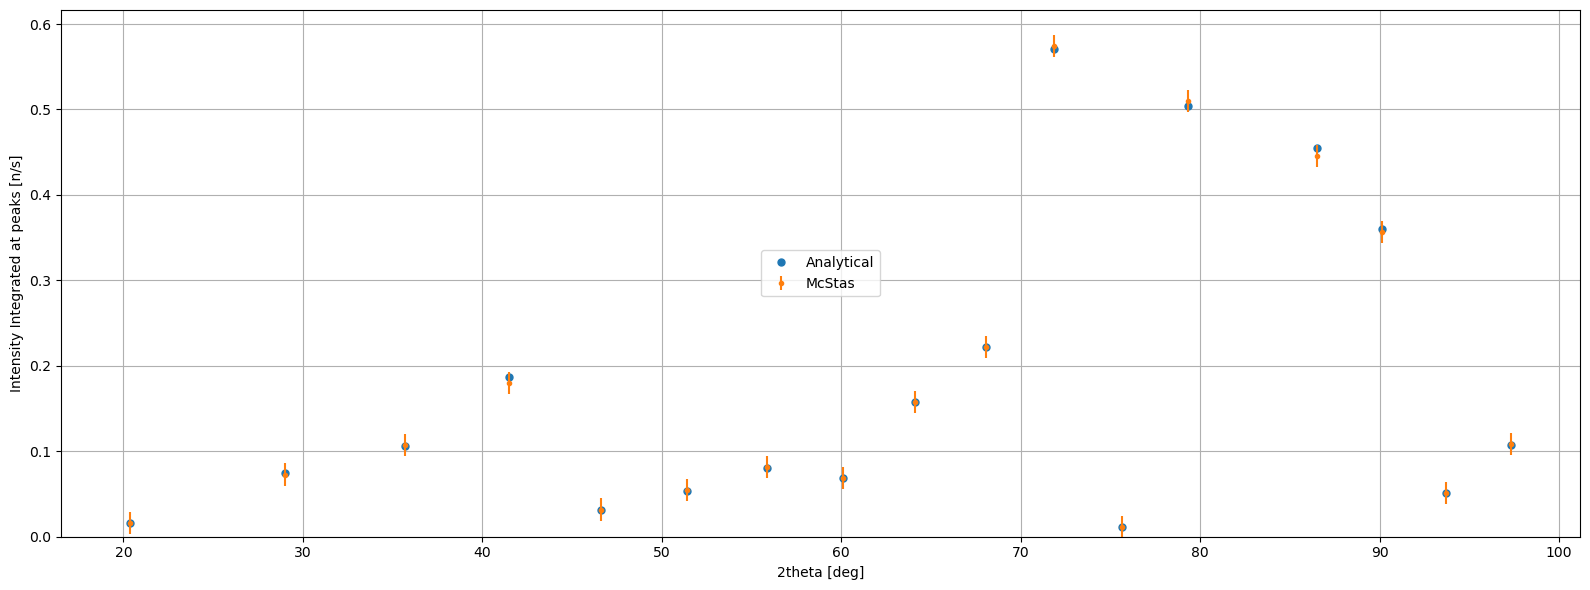

In [ ]:
fig, ax = plt.subplots(figsize=(16,6), ncols=1)

# ax2 = ax.twinx()
# ax.plot(nacalf_analytical[0], nacalf_analytical[1], 'r.',markersize=10,label='Analytical Vesta')
# ax.plot(nacalf_McStas[0], nacalf_McStas[1], '-',markersize=10,label='Analytical McStas')
ax.plot(nacalf_Full[0], nacalf_Full[1], '.',markersize=10,label='Analytical') # With fullprof
ax.errorbar(nacalf_analytical[0], data_int,yerr=errs, fmt='.', label='McStas simulation')

# ax2.errorbar(data.xaxis, data.Intensity, fmt='k-', label='McStas')


ax.legend(loc='center')

ax.set(ylim=(0))
# ax2.set(ylim=(0,0.4))
ax.grid(True)
ax.set(xlabel="2theta [deg]",ylabel="Intensity Integrated at peaks [n/s]")
# ax2.set(ylabel="Intensity [n/s] simulation output")
fig.tight_layout()
fig.savefig('')


In [103]:
# Copper
copper_anal = get_formfact('Copper.txt')
unit_cell_vol = 47.2416
rho = 1/unit_cell_vol # AA^-3
copper_anal = n_measured(flux, A, dist,h, unit_cell_vol, wavelength,r, copper_anal)


In [104]:
# Load the data and generate the simulated diffractogram
data = ms.load_data("../data/powder_cop")
data = data[-1]
print(data)
# split the data up into peaks
data_int = []
mask_areas = []
errs = []
for pos in copper_anal[0]:
    mask = (data.xaxis>(pos-1.5)) & (data.xaxis<(pos+1.5))
    mask_areas.append(data.xaxis[mask])
    intensity = np.sum(data.Intensity[mask])
    errs.append(np.sqrt(np.sum(data.Error**2)))
    data_int.append(intensity)


data_int = np.array(data_int)
print(f"Mcstas={data_int}\t Analytical={copper_anal[1]}\n")


McStasData: banana_mon type: 1D  I:9.80352 E:0.00600034 N:2819760.0
Mcstas=[6.01876084 3.78476359]	 Analytical=[6.01448351 3.78893367]



[Text(0.5, 0, '2theta [deg]'),
 Text(0, 0.5, 'Intensity [n/s] Analytical calculation')]

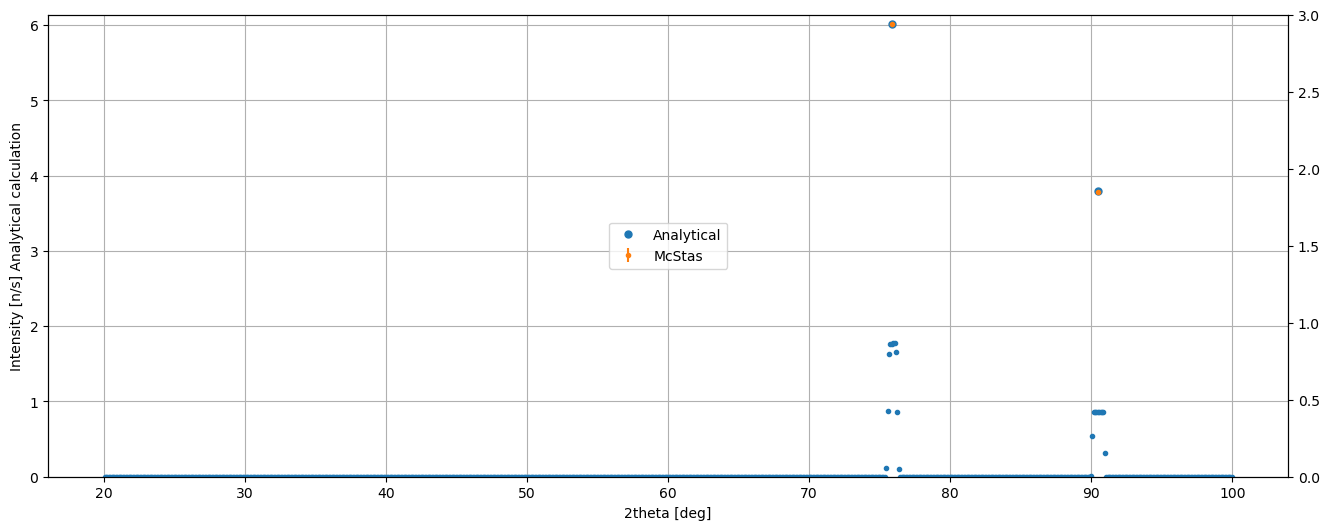

In [105]:
fig, ax = plt.subplots(figsize=(16,6), ncols=1)

ax2 = ax.twinx()
ax.plot(copper_anal[0], copper_anal[1], '.',markersize=10,label='Analytical')
ax.errorbar(copper_anal[0], data_int,yerr=errs, fmt='.', label='McStas')
ax2.errorbar(data.xaxis, data.Intensity, fmt='.', label='McStas')

ax.legend(loc='center')
# ax2.legend(loc='upper center')
ax.set(ylim=(0))
ax2.set(ylim=(0,3))
ax.grid(True)
ax.set(xlabel="2theta [deg]",ylabel="Intensity [n/s] Analytical calculation")
# ax2.set(ylabel="Intensity [n/s] McStas simulation")